In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

ordner = "/content/Daten"
dateien = glob.glob(os.path.join(ordner, "*.csv"))

df_liste = []

for datei in dateien:
    df_temp = pd.read_csv(datei, engine="python", on_bad_lines="skip", sep=";")
    df_temp["quelle_datei"] = os.path.basename(datei)
    df_liste.append(df_temp)

df = pd.concat(df_liste, ignore_index=True)

print(df.head())
print(df.info())

  english_term spanish_term  migrationsbezug_eng  migrationsbezug_spa  \
0      Adjourn    propostar                    0                    0   
1      Adjourn    propostar                    0                    0   
2      Adjourn    propostar                    0                    0   
3      Adjourn    propostar                    0                    0   
4      Adjourn    propostar                    0                    0   

   polysemie_eng  polysemie_spa  topic_number  \
0              1              1             2   
1              1              1             2   
2              1              1             2   
3              1              1             2   
4              1              1             2   

                                      topic  migrationsbezug_equal  \
0  Verfahren, Anträge, behördliche Prozesse                      1   
1  Verfahren, Anträge, behördliche Prozesse                      1   
2  Verfahren, Anträge, behördliche Prozesse             

In [2]:
clean_df = df[
    ~(
        (
            (df['qs_eng'].notna() & df['qs_migrationsbezug_eng_final'].isna()) |
            (df['qs_spa'].notna() & df['qs_migrationsbezug_spa_final'].isna())
        )
        |
        (df['english_term'] == "Naturalization certificate")
        |
         (df['english_term'] == "Petitioner")
        |
         (df['english_term'] == "Smuggling of migrants")
        |
         (df['english_term'] == "foreigner")

    )
].copy()

In [10]:
print(clean_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 266698 entries, 0 to 271238
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   english_term                  266698 non-null  object 
 1   spanish_term                  266698 non-null  object 
 2   migrationsbezug_eng           266698 non-null  int64  
 3   migrationsbezug_spa           266698 non-null  int64  
 4   polysemie_eng                 266698 non-null  int64  
 5   polysemie_spa                 266698 non-null  int64  
 6   topic_number                  266698 non-null  int64  
 7   topic                         266698 non-null  object 
 8   migrationsbezug_equal         266698 non-null  int64  
 9   migrationsbezug_any           266698 non-null  int64  
 10  migrationsbezug_both          266698 non-null  int64  
 11  qs_position                   266698 non-null  int64  
 12  qs_eng                        265445 non-null  ob

In [3]:
import pandas as pd

df = clean_df.copy()

# Sicherheit: numerisch
df['qs_migrationsbezug_eng_final'] = pd.to_numeric(df['qs_migrationsbezug_eng_final'], errors='coerce')
df['qs_migrationsbezug_spa_final'] = pd.to_numeric(df['qs_migrationsbezug_spa_final'], errors='coerce')

# Englisch
mean_eng = df[
    df['qs_migrationsbezug_eng_final'].notna()
]['qs_migrationsbezug_eng_final'].mean() * 100

# Spanisch
mean_spa = df[
    df['qs_migrationsbezug_spa_final'].notna()
]['qs_migrationsbezug_spa_final'].mean() * 100

print(f"Englisch: {mean_eng:.2f}%")
print(f"Spanisch: {mean_spa:.2f}%")

Englisch: 38.86%
Spanisch: 35.29%


                                 Englisch   Spanisch
Suchterme MIT Migrationsbezug   77.427954  74.582181
Suchterme OHNE Migrationsbezug   6.848692   5.389637


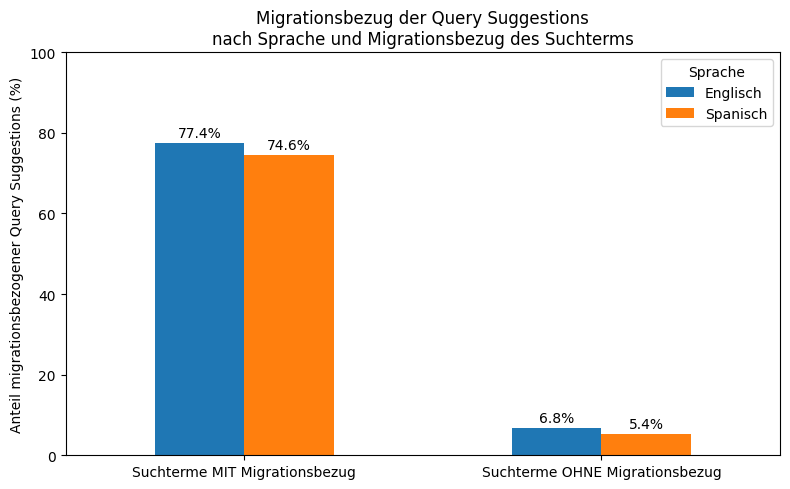

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Ausgangsbasis
# ------------------------------------------------------------
df = clean_df.copy()

# Sicherheit: numerisch
for col in [
    'qs_migrationsbezug_eng_final',
    'qs_migrationsbezug_spa_final',
    'migrationsbezug_eng',
    'migrationsbezug_spa'
]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ------------------------------------------------------------
# Funktion zur Berechnung
# ------------------------------------------------------------
def compute_qs_migration_share(df, term_migration_flag):
    """
    term_migration_flag:
        1 = Suchterme MIT Migrationsbezug
        0 = Suchterme OHNE Migrationsbezug
    """

    # Englisch
    eng = df[
        (df['qs_eng'].notna()) &
        (df['qs_migrationsbezug_eng_final'].notna()) &
        (df['migrationsbezug_eng'] == term_migration_flag)
    ]['qs_migrationsbezug_eng_final'].mean() * 100

    # Spanisch
    spa = df[
        (df['qs_spa'].notna()) &
        (df['qs_migrationsbezug_spa_final'].notna()) &
        (df['migrationsbezug_spa'] == term_migration_flag)
    ]['qs_migrationsbezug_spa_final'].mean() * 100

    return eng, spa

# ------------------------------------------------------------
# Werte berechnen
# ------------------------------------------------------------
eng_with, spa_with = compute_qs_migration_share(df, 1)
eng_without, spa_without = compute_qs_migration_share(df, 0)

# ------------------------------------------------------------
# DataFrame für Plot
# ------------------------------------------------------------
plot_df = pd.DataFrame({
    'Englisch': [eng_with, eng_without],
    'Spanisch': [spa_with, spa_without]
}, index=[
    'Suchterme MIT Migrationsbezug',
    'Suchterme OHNE Migrationsbezug'
])

print(plot_df)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
ax = plot_df.plot(kind='bar', figsize=(8, 5))

plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('')
plt.ylim(0, 100)
plt.title('Migrationsbezug der Query Suggestions\nnach Sprache und Migrationsbezug des Suchterms')

plt.xticks(rotation=0)
plt.legend(title='Sprache')

# Werte anzeigen
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np
from itertools import combinations

def compute_jaccard_by_term(df, lang, migration_flag):
    """
    lang: 'eng' oder 'spa'
    migration_flag: 1 (mit) oder 0 (ohne)
    """

    qs_col = f'qs_{lang}'
    term_col = 'english_term' if lang == 'eng' else 'spanish_term'
    term_mig_col = f'migrationsbezug_{lang}'

    subset = df[
        (df[qs_col].notna()) &
        (df[term_col].notna()) &
        (df[term_mig_col].notna()) &
        (df[term_mig_col] == migration_flag)
    ].copy()

    # Standort-ID
    subset['location_id'] = (
        subset['land'].astype(str) + " | " +
        subset['bundesstaat'].astype(str) + " | " +
        subset['stadt'].astype(str)
    )

    # Sets pro Term & Standort
    term_location_sets = (
        subset.groupby([term_col, 'location_id'])[qs_col]
        .apply(lambda x: set(x.dropna().astype(str).str.strip()))
        .reset_index(name='qs_set')
    )

    # Pairwise Jaccard
    results = []

    for term, group in term_location_sets.groupby(term_col):
        location_sets = list(zip(group['location_id'], group['qs_set']))

        if len(location_sets) < 2:
            continue

        for (_, set1), (_, set2) in combinations(location_sets, 2):
            union = set1 | set2
            if len(union) == 0:
                score = np.nan
            else:
                score = len(set1 & set2) / len(union)

            results.append(score)

    return pd.Series(results, name=f'{lang}_{migration_flag}')

In [8]:
# Englisch
eng_with = compute_jaccard_by_term(clean_df, 'eng', 1)
eng_without = compute_jaccard_by_term(clean_df, 'eng', 0)

# Spanisch
spa_with = compute_jaccard_by_term(clean_df, 'spa', 1)
spa_without = compute_jaccard_by_term(clean_df, 'spa', 0)

/tmp/ipykernel_5573/306982311.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels)


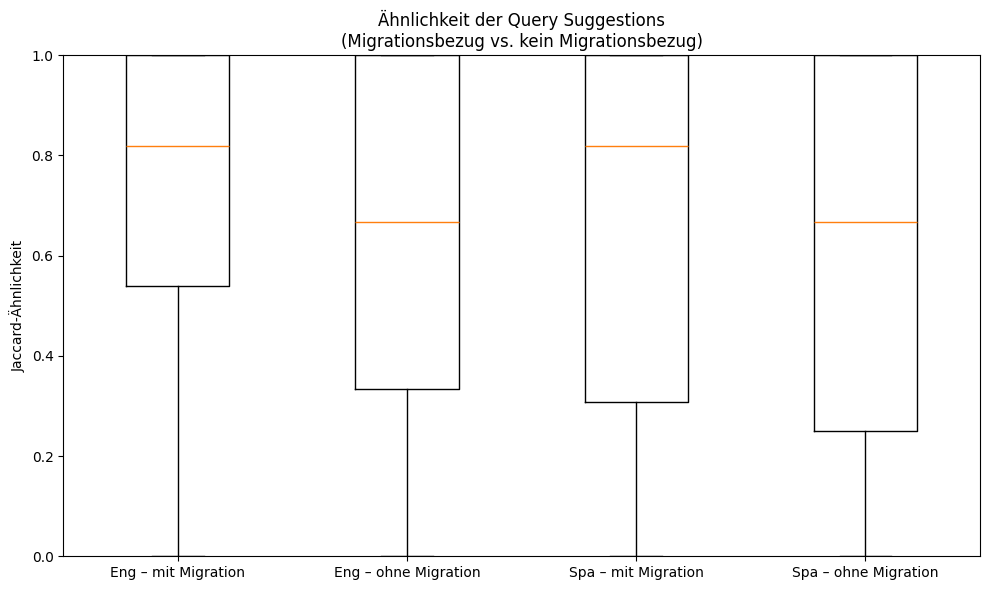

In [9]:
import matplotlib.pyplot as plt

plot_data = [
    eng_with.dropna(),
    eng_without.dropna(),
    spa_with.dropna(),
    spa_without.dropna()
]

labels = [
    'Eng – mit Migration',
    'Eng – ohne Migration',
    'Spa – mit Migration',
    'Spa – ohne Migration'
]

plt.figure(figsize=(10, 6))
plt.boxplot(plot_data, labels=labels)

plt.ylabel('Jaccard-Ähnlichkeit')
plt.title('Ähnlichkeit der Query Suggestions\n(Migrationsbezug vs. kein Migrationsbezug)')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [18]:
#Betrachtung des durchschnittlichen Jaccard Index
print(
    "Englisch mit ", eng_with.mean(), "\n",
    "Englisch ohne ", eng_without.mean(), "\n",
    "Spanisch mit ", spa_with.mean(), "\n",
    "Spanisch ohne ", spa_without.mean()
)

Englisch mit  0.7426118732842845 
 Englisch ohne  0.6146125306692568 
 Spanisch mit  0.6546946717083079 
 Spanisch ohne  0.6021960339585051


In [19]:
#Betrachtung des Median des Jaccard Index
print(
    "Englisch mit ", eng_with.median(), "\n",
    "Englisch ohne ", eng_without.median(), "\n",
    "Spanisch mit ", spa_with.median(), "\n",
    "Spanisch ohne ", spa_without.median()
)

Englisch mit  0.8181818181818182 
 Englisch ohne  0.6666666666666666 
 Spanisch mit  0.8181818181818182 
 Spanisch ohne  0.6666666666666666


In [22]:
quantiles = [0.25, 0.5, 0.75]

table = pd.DataFrame({
    "Quantil": quantiles,
    "Englisch": eng_with.quantile(quantiles).values,
    "Spanisch": spa_with.quantile(quantiles).values
})

print(table)

   Quantil  Englisch  Spanisch
0     0.25  0.538462  0.307692
1     0.50  0.818182  0.818182
2     0.75  1.000000  1.000000
